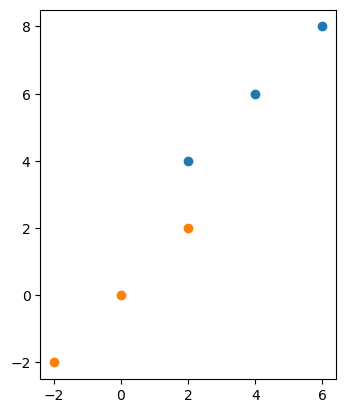

In [13]:
# 원본 데이터 => 평균 제거 => PCA적용 => 변환데이터
# 각 Feature의 평균을 빼서 데이터의 중심을 원점으로 옮기기
import matplotlib.pyplot as plt
import numpy as np
ax = plt.subplot(1,1,1,aspect='equal')
x = np.array( [[2, 4], [4,6], [6,8]] )
ax.scatter(x[:,0], x[:,1])
x -= x.mean(axis=0).astype(int)
ax.scatter(x[:,0], x[:,1])

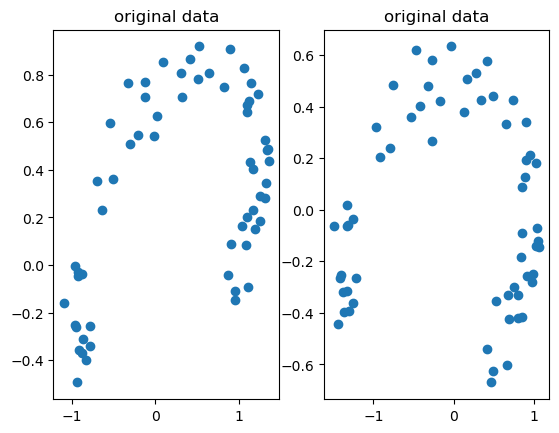

In [17]:
import numpy as np
np.random.seed(42)
m = 60
# 3차원 데이터
w1, w2 = 0.1, 0.3
noise = 0.3

angle = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X = np.empty((m,3))

# 서로 약간 상관관계가 있는 구조
X[:,0] = np.cos(angle) + np.sin(angle)/2 + noise*np.random.rand(m)
X[:,1] = np.sin(angle) * 0.7 + noise * np.random.rand(m)
X[:,2] = X[:,0] * w1 + X[:,1] * w2 + noise * np.random.rand(m)

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

# 변환전 (X의 일부 차원만 시각화)
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1])
plt.title('original data')

plt.subplot(1,2,2)
plt.scatter(X2D[:,0], X2D[:,1])
plt.title('original data')

plt.show()

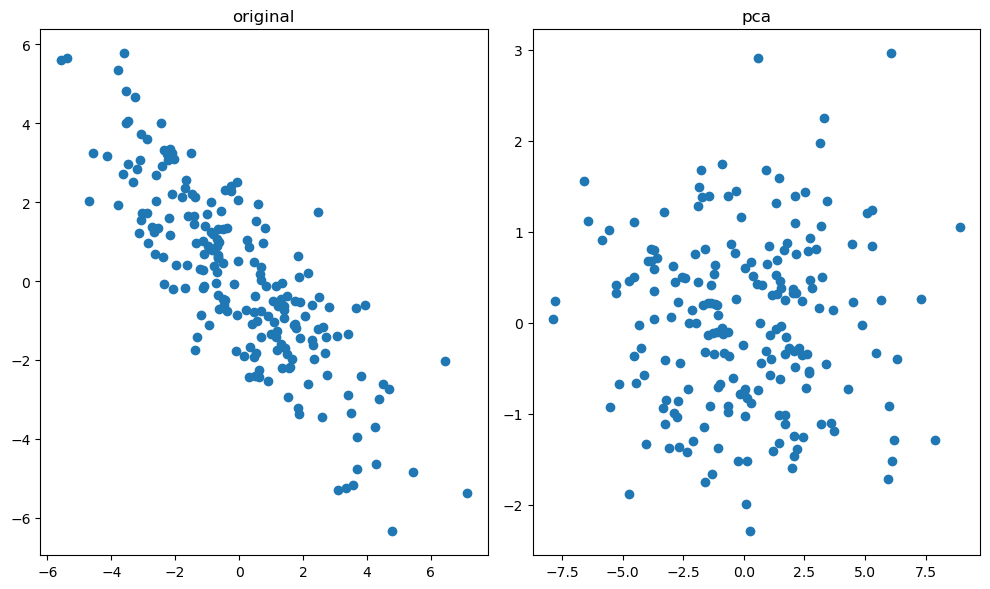

In [23]:
import numpy as np
from sklearn.decomposition import PCA
# 파원형 데이터 생성
m = 200
# 길게 늘어진 직선형태
X = np.random.randn(m, 2)
X[:, 0]*=3
# 회전(기울기)
theta = np.pi / 4 # 45도 회전
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
X = X@rotation_matrix

# PCA 적용
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(10,6))
axes[0].scatter(X[:,0], X[:,1])
axes[0].set_title('original')

axes[1].scatter(X2D[:,0], X2D[:,1])
axes[1].set_title('pca')

plt.tight_layout()
plt.show()

In [ ]:
# wine dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.datasets import load_wine
from sklearn.svm import SVC, LinearSVC
# 데이터 + 모델 조합 성능측정
# 데이터(PCA변환) + 모델 조합 성능측정
data = load_wine()

X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr' , LogisticRegression())
])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
print("로지스틱")
print(classification_report(y_test, y_pred))

randomf = RandomForestClassifier()
randomf.fit(x_train, y_train)
y_pred = randomf.predict(x_test)
print("랜덤 포레스트")
print(classification_report(y_test, y_pred))

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('SVC', SVC())
])
pipeline.fit(x_train,y_train)
y_pred = pipeline.predict(x_test)
print("서포트벡터머신")
print(classification_report(y_test, y_pred))

pca = PCA(n_components=4)
X2D = pca.fit_transform(X)
x_train,x_test,y_train,y_test = train_test_split(X2D, y, test_size = 0.2, random_state = 42, stratify = y)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr' , LogisticRegression())
])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
print("로지스틱")
print(classification_report(y_test, y_pred))

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('SVC', SVC())
])
pipeline.fit(x_train,y_train)
y_pred = pipeline.predict(x_test)
print("서포트벡터머신")
print(classification_report(y_test, y_pred))

randomf = RandomForestClassifier()
randomf.fit(x_train, y_train)
y_pred = randomf.predict(x_test)
print("랜덤 포레스트")
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# 데이터 + 모델 조합 성능측정
# 데이터(PCA변환) + 모델 조합 성능측정
data = load_wine()

X = data.data
y = data.target

pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components = 2))
])
from sklearn.linear_model import SGDClassifier, ElasticNetCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, BaggingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
models = {'sgd':SGDClassifier(random_state=42), 'randomF':RandomForestClassifier(random_state=42), 
    'tree':DecisionTreeClassifier(random_state=42), 'svc': SVC(random_state=42, probability=True)}
for name, model in models.items():
    model = model
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    fold = StratifiedKFold(shuffle=True, random_state=42)
    y_predict = cross_val_predict(model, X_scaled, y, cv=fold)
    print( name )
    print( classification_report(y, y_predict) )
    

In [63]:
from sklearn.svm import SVC

voting = VotingClassifier([
    ('sgd', SGDClassifier(random_state=42, loss='log_loss')),
    ('randomF', RandomForestClassifier(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42)),
    ('svc', SVC(random_state=42, probability=True))
], voting = 'soft')

y_predict = cross_val_predict(voting, X_scaled, y, cv=fold)
print( classification_report(y, y_predict) )
50
bagging = BaggingClassifier(voting ,n_estimators=50, random_state=42)
y_predict = cross_val_predict(bagging, X_scaled, y, cv=fold)
print( classification_report(y, y_predict) )

stcking = StackingClassifier([
    ('sgd', SGDClassifier(random_state=42, loss='log_loss')),
    ('randomF', RandomForestClassifier(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42)),
    ('svc', SVC(random_state=42, probability=True))
],final_estimator=LogisticRegression(random_state=42))
y_predict = cross_val_predict(stcking, X_scaled, y, cv=fold)
print( classification_report(y, y_predict) )

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        59
           1       0.97      0.99      0.98        71
           2       0.98      0.98      0.98        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      0.99      0.99        71
           2       0.98      1.00      0.99        48

    accuracy                           0.99       178
   macro avg       0.99      1.00      0.99       178
weighted avg       0.99      0.99      0.99       178

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.97      0.99      0.98        71
           2       0.98      0.96      0.97        48

    accuracy        

In [67]:
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=2))
])
x_pipeline = pipeline.fit_transform(X)
stcking = StackingClassifier([
    ('sgd', SGDClassifier(random_state=42, loss='log_loss')),
    ('randomF', RandomForestClassifier(random_state=42)),
    ('tree', DecisionTreeClassifier(random_state=42)),
    ('svc', SVC(random_state=42, probability=True))
],final_estimator=LogisticRegression(random_state=42))
y_predict = cross_val_predict(stcking, X_scaled, y, cv=fold)
print( classification_report(y, y_predict) )

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       0.97      0.99      0.98        71
           2       0.98      0.96      0.97        48

    accuracy                           0.98       178
   macro avg       0.98      0.98      0.98       178
weighted avg       0.98      0.98      0.98       178



In [71]:
# n_components 찾기 누적 분산
import numpy as np
pca = PCA(n_components=10)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)
cumsum_variable = np.cumsum(
    pca.explained_variance_ratio_
)
print( cumsum_variable ) # 95% 이상이면 좋음, 90% 이상이면 빠르게 찾을 때, 99% 이상 => 정보 보존이 중요
np.argmax( cumsum_variable>=0.95 ) + 1

[0.32853032 0.52534437 0.65218765 0.73007254 0.79975362 0.85582868
 0.90392525 0.92934163 0.9502528  0.96780032]


np.int64(9)

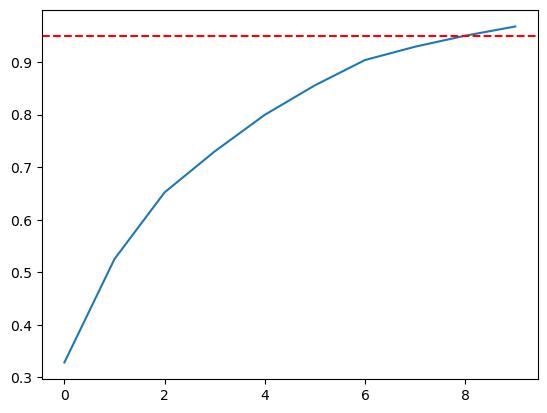

In [ ]:
# 시각적 엘보우 ... 급격히 증가후 완만해지는 구간
import matplotlib.pyplot as plt
plt.plot(cumsum_variable)
plt.axhline(y=0.95, linestyle='--', c='r')

In [ ]:
# 자동으로 찾기
# n_components 찾기 누적 분산
import numpy as np
pca = PCA(n_components=0.95) # 95%의 분산을 설명하는 최소 component 자동선택
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)

print(pca.n_components_)

9


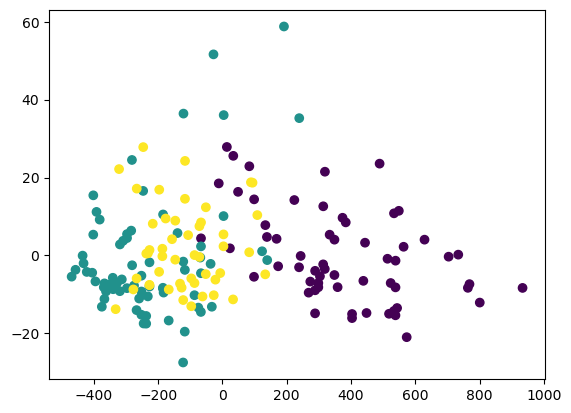

In [ ]:
# 시각화
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

wine = load_wine()
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X)
plt.scatter(x_pca[:,0], x_pca[:,1], c=y)
plt.show()